In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [5]:
df = pd.read_csv("input_traincopy.csv")

print("Shape:", df.shape)
df.head()

Shape: (787, 339)


,PTID_Key,EXAMDATE,T,AGE,PTGENDER,PTEDUCAT,PTETHCAT,PTRACCAT,PTMARRY,APOE4,...,ST97TS_UCSFFSX_11_02_15_UCSFFSX51_08_01_16,ST98CV_UCSFFSX_11_02_15_UCSFFSX51_08_01_16,ST98SA_UCSFFSX_11_02_15_UCSFFSX51_08_01_16,ST98TA_UCSFFSX_11_02_15_UCSFFSX51_08_01_16,ST98TS_UCSFFSX_11_02_15_UCSFFSX51_08_01_16,ST99CV_UCSFFSX_11_02_15_UCSFFSX51_08_01_16,ST99SA_UCSFFSX_11_02_15_UCSFFSX51_08_01_16,ST99TA_UCSFFSX_11_02_15_UCSFFSX51_08_01_16,ST99TS_UCSFFSX_11_02_15_UCSFFSX51_08_01_16,ST9SV_UCSFFSX_11_02_15_UCSFFSX51_08_01_16
0,8,11/1/12,11,71.4,1,18,1,1,2,0,...,0.674000,3875.000000,1528.000000,2.370000,0.562000,8909.00000,2714.000000,2.80300,0.596000,1267.000000
1,18,8/6/12,6,73.0,2,17,1,2,1,0,...,0.512144,5356.795456,1959.950778,2.280803,0.898805,13162.66608,3998.553339,2.71624,0.680506,2112.519617
2,21,12/20/12,4,55.0,2,16,1,2,1,2,...,0.532000,5047.000000,1908.000000,2.341000,0.931000,15998.00000,4388.000000,2.88100,0.910000,1838.000000
3,21,12/20/12,10,55.0,2,16,1,2,1,2,...,0.532000,5047.000000,1908.000000,2.341000,0.931000,15998.00000,4388.000000,2.88100,0.910000,1838.000000
4,21,12/20/12,22,55.0,2,16,1,2,1,2,...,0.532000,5047.000000,1908.000000,2.341000,0.931000,15998.00000,4388.000000,2.88100,0.910000,1838.000000


In [6]:
core_features = [
    'AGE',
    'APOE4',
    'ADAS13',
    'CDRSB',
    'FAQ',
    'RAVLT_immediate',
    'Ventricles',
    'WholeBrain',
    'ICV',
    'PTEDUCAT',
    'MMSE'
]

df = df[core_features]

print("Selected columns:", len(df.columns))

Selected columns: 11


In [7]:
df = df[(df["WholeBrain"] > 0) & (df["Ventricles"] > 0)]
df = df.reset_index(drop=True)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 776 entries, 0 to 775
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   AGE              776 non-null    float64
 1   APOE4            776 non-null    int64  
 2   ADAS13           776 non-null    float64
 3   CDRSB            776 non-null    float64
 4   FAQ              776 non-null    float64
 5   RAVLT_immediate  776 non-null    float64
 6   Ventricles       776 non-null    float64
 7   WholeBrain       776 non-null    float64
 8   ICV              776 non-null    float64
 9   PTEDUCAT         776 non-null    int64  
 10  MMSE             776 non-null    float64
dtypes: float64(9), int64(2)
memory usage: 66.8 KB
None


In [8]:
df["BrainHealthyRatio"] = df["WholeBrain"] / df["ICV"]
df["VentricularRatio"] = df["Ventricles"] / df["ICV"]
df["AtrophyIndex"] = df["Ventricles"] / df["WholeBrain"]

In [9]:
X = df.drop(columns=['MMSE'])
y = df['MMSE']

print(X.shape)

(776, 13)


In [10]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
import pandas as pd
X = pd.DataFrame(X_scaled, columns=X.columns)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [13]:
mae = mean_absolute_error(y_test, y_pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost Results:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

XGBoost Results:
MAE: 0.7233018016072277
RMSE: 1.4455099873493962
R2 Score: 0.6819629952948474


In [14]:
xgb_importance = xgb.feature_importances_

xgb_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_importance
})

xgb_importance_df = xgb_importance_df.sort_values(by="Importance", ascending=False)

xgb_importance_df.head(15)

,Feature,Importance
3,CDRSB,0.442844
5,RAVLT_immediate,0.139729
2,ADAS13,0.097965
4,FAQ,0.057951
9,PTEDUCAT,0.040812
1,APOE4,0.038548
11,VentricularRatio,0.031838
10,BrainHealthyRatio,0.030985
12,AtrophyIndex,0.029802
7,WholeBrain,0.025884


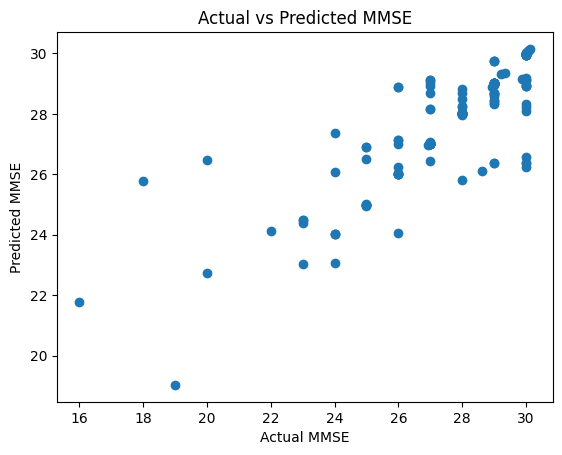

In [15]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_xgb)
plt.xlabel("Actual MMSE")
plt.ylabel("Predicted MMSE")
plt.title("Actual vs Predicted MMSE")
plt.show()

In [21]:
game_input = {
    'AGE': 65,
    'APOE4': 0,

    'accuracy': 90,
    'mistakes': 1,
    'max_mistakes': 10,
    'time_taken': 20,
    'max_time': 60,
    'learning_score': 8,
    'max_learning': 10
}

In [28]:
from sklearn.preprocessing import StandardScaler
import joblib
import pandas as pd

# Initialize scaler
scaler = StandardScaler()

# Fit + transform training data
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X = pd.DataFrame(X_scaled, columns=X.columns)

# Save scaler
joblib.dump(scaler, "scaler.pkl")

print("Scaler saved successfully")

Scaler saved successfully


In [38]:
def game_to_clinical(game_data):
    
    acc = game_data['accuracy'] / 100
    mistakes = game_data['mistakes'] / game_data['max_mistakes']
    time = game_data['time_taken'] / game_data['max_time']
    learning = game_data['learning_score'] / game_data['max_learning']
    
    clinical = {}
    
    # Memory
    clinical['RAVLT_immediate'] = acc * 60
    clinical['RAVLT_learning'] = learning * 10
    clinical['RAVLT_forgetting'] = mistakes * 15
    clinical['RAVLT_perc_forgetting'] = mistakes * 100
    
    # Cognitive
    cognitive_score = (0.5 * mistakes + 0.3 * time + 0.2 * (1 - learning))
    clinical['ADAS11'] = cognitive_score * 30
    clinical['ADAS13'] = cognitive_score * 60
    
    # Functional
    clinical['CDRSB'] = time * 18
    clinical['FAQ'] = (mistakes + time) / 2 * 30
    
    return clinical

In [48]:
def add_static_features(clinical, game_data, df):
    
    full_input = {
        'AGE': game_data['AGE'],
        'APOE4': game_data['APOE4'],
        
        # MRI features (only if present)
        'Ventricles': df['Ventricles'].mean() if 'Ventricles' in df.columns else 0,
        'WholeBrain': df['WholeBrain'].mean() if 'WholeBrain' in df.columns else 0,
        'ICV': df['ICV'].mean() if 'ICV' in df.columns else 1,  # avoid division by zero
        
        # Optional features
        'PTEDUCAT': 12,
        'T': 0,
        'Year': 0,
        'Month': 0
    }
    
    # Only add VN if exists
    if 'VN' in df.columns:
        full_input['VN'] = df['VN'].mean()
    
    # Merge clinical features
    full_input.update(clinical)
    
    return full_input

In [49]:
def add_engineered_features(input_df):
    
    if 'WholeBrain' in input_df.columns and 'ICV' in input_df.columns:
        input_df["BrainHealthyRatio"] = input_df["WholeBrain"] / input_df["ICV"]
    
    if 'Ventricles' in input_df.columns and 'ICV' in input_df.columns:
        input_df["VentricularRatio"] = input_df["Ventricles"] / input_df["ICV"]
    
    if 'Ventricles' in input_df.columns and 'WholeBrain' in input_df.columns:
        input_df["AtrophyIndex"] = input_df["Ventricles"] / input_df["WholeBrain"]
    
    return input_df

In [50]:
def prepare_input(game_data, df, X_columns, scaler):
    
    # Step 1: Game → clinical
    clinical = game_to_clinical(game_data)
    
    # Step 2: Add static features
    full_input = add_static_features(clinical, game_data, df)
    
    # Step 3: Convert to DataFrame
    input_df = pd.DataFrame([full_input])
    
    # Step 4: Feature engineering
    input_df = add_engineered_features(input_df)
    
    # Step 5: Align columns
    input_df = input_df.reindex(columns=X_columns, fill_value=0)
    
    # Step 6: Scale (IMPORTANT)
    input_scaled = scaler.transform(input_df)
    
    return input_scaled

In [51]:
import joblib

scaler = joblib.load("scaler.pkl")

In [57]:
game_alz = {
    'AGE': 65,
    'APOE4': 0,
    'accuracy': 35,
    'mistakes': 8,
    'max_mistakes': 10,
    'time_taken': 55,
    'max_time': 60,
    'learning_score': 2,
    'max_learning': 10
}

In [58]:
game_normal = {
    'AGE': 65,
    'APOE4': 0,
    'accuracy': 90,
    'mistakes': 1,
    'max_mistakes': 10,
    'time_taken': 20,
    'max_time': 60,
    'learning_score': 8,
    'max_learning': 10
}

In [62]:
game_mci = {
    'AGE': 65,
    'APOE4': 0,
    'accuracy': 65,
    'mistakes': 4,
    'max_mistakes': 10,
    'time_taken': 35,
    'max_time': 60,
    'learning_score': 5,
    'max_learning': 10
}

In [63]:
def predict(game_data):
    
    input_scaled = prepare_input(game_data, df, X.columns, scaler)
    
    pred = xgb.predict(input_scaled)[0]
    
    return pred

In [64]:
print("Normal:", predict(game_normal))
print("MCI:", predict(game_mci))
print("Alzheimer:", predict(game_alz))

Normal: 24.584297
MCI: 24.584297
Alzheimer: 24.584297
